# Computational control - Bonus Tutorial:
# Data-enabled Predictive Control (DeePC) and the Projection Regularizer

This tutorial examines two different regularizers for DeePC algorithm--the "Standard Regularizer," and the "Projection Regularizer."

Additional insight can be found in Prof. Dörfler's paper, [Bridging direct & indirect data-driven control formulations via regularizations and relaxations](https://arxiv.org/pdf/2101.01273).

As with the tutorial that introduced DeePC, we will look at a standard double integrator system.

### Package imports

In [1]:
import numpy as np                         # For linear algebra
import cvxpy as cp                         # For optimization
import matplotlib.pyplot as plt            # For plots
from scipy.linalg import svdvals           # For computing singular values
np.set_printoptions(precision=3)           # Set nice printing format
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import pairwise_distances
from scipy.linalg import cho_factor, cho_solve
from sklearn.neighbors import NearestNeighbors

Double Integrator System

In [2]:
dt = .1
mass = 1

A = np.array([[1, dt],
              [0, 1]])
B = np.array([[(dt/mass)**2/2],
              [dt/mass]])
C = np.array([[1, 0]])

# System constants
n = np.shape(A)[0] # state dimension
m = np.shape(B)[1] # input dimension
p = np.shape(C)[0] # output dimension

**Gather data**

The code below gathers data and investigates the impact of noise on the singular values of the Hankel matrix.

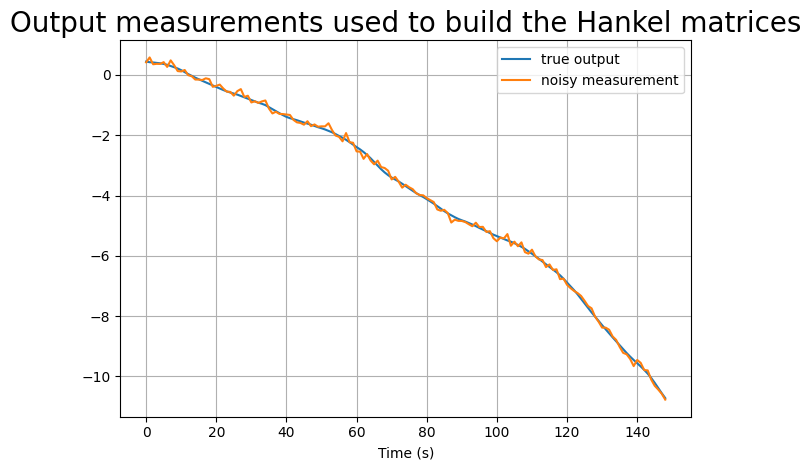

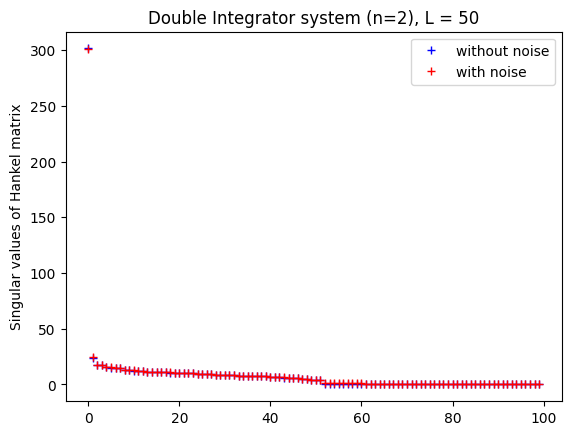

In [3]:
np.random.seed(5) # for debugging. You can set the random seed so that there is not variance between runs. This may or may not be useful.

# Set Hankel dimensions
T_past = 20 # T_past is the number of timesteps into the past that the DeePC optimization considers.
T_fut = 30 # T_future is the number of timesteps into the future that the DeePC optimization plans for.
L = T_past+T_fut

T_hankel = 3*L-1 # T_hankel is the number of data points used to build the Hankel matrix
# (3*L-1 is an arbitrary choice, and not optimal)

s_noise = 0.1 # the standard deviation of the output measurement

# Collect data
x_data = np.zeros((T_hankel+1,2))
u_data = np.zeros((T_hankel,1))
y_data = np.zeros((T_hankel,1))
y_data_noisy = np.zeros((T_hankel,1))

x_data[0] = np.reshape(np.random.randn(n,1),n)*1 # initial condition

s_input = 1 # the standard deviation of the gaussian excitation used to perturb the system to gather persistently-excited data

# Gather data
for i in range(T_hankel):
    u_data[i] = np.random.randn(1)*s_input
    x_data[i+1] = A@x_data[i] + B@u_data[i]
    y_data[i] = C@x_data[i]
    y_data_noisy[i] = C@x_data[i] + np.random.randn(p,1)*s_noise

plt.plot(range(0,T_hankel), y_data, label='true output')
plt.plot(range(0,T_hankel), y_data_noisy, label='noisy measurement')
plt.xlabel('Time (s)')
plt.title("Output measurements used to build the Hankel matrices", fontdict={'fontsize':20})
plt.grid('on')
plt.tight_layout()
plt.legend()
plt.show()

# Build Hankel matrices
num_hankel_cols = T_hankel - L
H_u = u_data[:L]
H_y = y_data[:L]
H_y_noisy = y_data_noisy[:L]

for i in range(num_hankel_cols):
    H_u = np.hstack((H_u,u_data[i:i+L]))
    H_y = np.hstack((H_y,y_data[i:i+L]))
    H_y_noisy = np.hstack((H_y_noisy,y_data_noisy[i:i+L]))

H = np.vstack((H_u,H_y))

# Calculate the singular values for comparison
singular_values = svdvals(H)
rank_hankel = np.linalg.matrix_rank(H)

H_noisy = np.vstack((H_u,H_y_noisy))
singular_values_noisy = svdvals(H_noisy)
rank_hankel_noisy = np.linalg.matrix_rank(H_noisy)

plt.plot(singular_values,'b+',label='without noise')
plt.plot(singular_values_noisy,'r+',label='with noise')
plt.ylabel('Singular values of Hankel matrix')
plt.title(f'Double Integrator system (n=2), L = {L}')
plt.legend()
plt.show()

**Build Kernel DeePC matrices**

In [4]:
Hu_past = H_u[:m*T_past, :]
Hu_future = H_u[-m*T_fut:, :]
Hy_past = H_y[:p*T_past, :]
Hy_future = H_y[-p*T_fut:, :]

print(Hu_past.shape)
print(Hu_future.shape)
print(Hy_past.shape)
print(Hy_future.shape)

X1_full = np.vstack([Hu_past, Hy_past]) # shape (d1, Hc_sub)
X2_full = Hu_future # shape (d2, Hc_sub)
YF_full = Hy_future # shape (pN, Hc_sub)

Hc = X1_full.shape[1]

# Train/Validation split over columns 
rng = np.random.default_rng(0)
perm = rng.permutation(Hc)
train_ratio = 0.8
n_tr = int(train_ratio * Hc)
idx_tr, idx_va = perm[:n_tr], perm[n_tr:]

X1_tr, X1_va = X1_full[:, idx_tr], X1_full[:, idx_va]
X2_tr, X2_va = X2_full[:, idx_tr], X2_full[:, idx_va]
YF_tr, YF_va = YF_full[:, idx_tr], YF_full[:, idx_va]

def rbf_gamma_knn(X1_cols, k=7):
    """
    X1_cols: (d1, Hc) with columns as data points (u_ini;y_ini)
    k: kth neighbor used to set locality (typ. 5..10)
    Returns gamma = 1 / d_k^2
    """
    X = X1_cols.T  # shape (Hc, d1)
    k = min(k, max(1, X.shape[0]-1))  # guard
    nn = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X)
    dists, _ = nn.kneighbors(X)         # includes self at index 0
    dk = np.median(dists[:, k])         # median k-th neighbor distance
    return 1.0 / (dk**2 + 1e-12)

best_gamma_rbf = rbf_gamma_knn(X1_tr, k=7) * 1e-2
print("Best gamma_rbf (k-NN heuristic):", best_gamma_rbf)

# Mixed Kernel: RBF on X1, Linear on X2
def mixed_kernel_gram(X1A, X2A, X1B, X2B, gamma_rbf):
    K_rbf = rbf_kernel(X1A.T, X1B.T, gamma=gamma_rbf)
    K_lin = X2A.T @ X2B
    return K_rbf + K_lin

X1 = np.vstack((Hu_past, Hy_past))  # (m*T_ini + p*T_ini, Hc)
X2 = Hu_future                      # (m*N, Hc)

# RBF term (on X1 columns)
# # sklearn's rbf_kernel uses gamma = 1 / (2sigma^2)
K_rbf = rbf_kernel(X1.T, X1.T, gamma=best_gamma_rbf)  # (Hc, Hc)

# Linear term (on X2 columns)
K_lin = X2.T @ X2   # (Hc, Hc)
K = K_rbf + K_lin

print(K.shape)

# (Optional sanity check: mean off-diagonal similarity; aim ~0.05 - 0.3)
m_off = K_rbf[~np.eye(K_rbf.shape[0], dtype=bool)].mean()
print("Mean off-diag of K_rbf:", m_off)

(20, 100)
(30, 100)
(20, 100)
(30, 100)
Best gamma_rbf (k-NN heuristic): 0.000241636156987593
(100, 100)
Mean off-diag of K_rbf: 0.9586917909490481


**Define the DeePC controller**

In [5]:
class DeePCcontrollerClass:
    def __init__(self, T_hankel, T_past, T_fut, r, q, lam_g_stan, lam_g_proj, lam_sigma, H_u, H_y, solver):

        self.solver = solver

        self.T_hankel = T_hankel
        self.T_past = T_past
        self.T_fut = T_fut
        self.L = self.T_past + self.T_fut

        self.r = r # input cost weight
        self.q = q # output ~
        self.lam_g_stan = lam_g_stan # weight for the Standard g regularization
        self.lam_g_proj = lam_g_proj # weight for the Projection g regularization
        self.lam_sigma = lam_sigma # weight for the sigma regularization  (usually large works well)

        # offline data
        self.H_u = H_u
        self.H_y = H_y

        if self.lam_g_proj != 0:
            H = np.vstack((self.H_u, self.H_y[:p*T_past]))
            Pi = np.linalg.pinv(H)@H
            I = np.eye(Pi.shape[0])
            self.HkernelProjMat = I - Pi


    def step(self, u_p, y_p, y_ref):
        """
        Returns the first action of input sequence.
        """
        verbose=False

        # set up the DeePC optimization in CVX
        # Helpful CVX functions: cp.Variable(), cp.quad_form()

        g = cp.Variable(self.T_hankel - self.L +1)
        u_f = cp.Variable(self.T_fut)
        y_f = cp.Variable(self.T_fut)
        sigma = cp.Variable(self.T_past)

        if self.lam_g_proj == 0:
            cost = self.q*cp.quad_form(y_f-y_ref, np.eye(T_fut)) + self.r*cp.quad_form(u_f, np.eye(T_fut)) + self.lam_g_stan*cp.atoms.norm(g,1) + self.lam_sigma*cp.atoms.norm(sigma,2)
        else:
            cost = self.q*cp.quad_form(y_f-y_ref, np.eye(T_fut)) + self.r*cp.quad_form(u_f, np.eye(T_fut)) + self.lam_g_stan*cp.atoms.norm(g,1) + self.lam_g_proj*cp.sum_squares(self.HkernelProjMat@g) + self.lam_sigma*cp.atoms.norm(sigma,2)

        U_p = self.H_u[:m*T_past]
        U_f = self.H_u[m*T_past:]
        Y_p = self.H_y[:p*T_past]
        Y_f = self.H_y[p*T_past:]

        constraints = [
            U_p@g == u_p,
            U_f@g == u_f,
            Y_p@g == y_p + sigma,
            Y_f@g == y_f
        ]

        prob = cp.Problem(cp.Minimize(cost), constraints)
        if self.solver is None:
            prob.solve(verbose=False)
        else:
            prob.solve(verbose=False, solver=self.solver)
        if prob.status not in ['optimal', 'optimal_inaccurate']:
            raise Exception(f'cvx had an issue with the optimization. got prob.status: {prob.status}')

        return u_f.value, y_f.value, g.value, sigma.value

**Define KernelDeePC (with g)**

In [6]:
class KernelDeePCcontrollerClass:
    """
    Class for your kernel DeePC optimization.
    """

    def __init__(self, r_kernel, q_kernel, lambda_g_kernel, lambda_k_kernel, gamma):
        """

        """
        # Extract dimensions
        self.m, self.p = m, p

        # Horizons
        self.T_ini = T_past
        self.N = T_fut

        # Extract cost matrices
        self.R = r_kernel * np.eye(self.m * self.N)
        self.Q = q_kernel * np.eye(self.p * self.N)

        # Extract Kernel and Hankel matrices
        self.K = K
        self.Hc = self.K.shape[0]
        self.gamma = gamma # regularization parameter for K
        self.Kg = self.K + self.gamma*np.eye(self.Hc)
        self.X = np.vstack((Hu_past, Hy_past, Hu_future))
        self.Hy_future = Hy_future
        self.rbf_scale = best_gamma_rbf

        # Regularization weights
        self.lambda_g = lambda_g_kernel
        self.lambda_k = lambda_k_kernel

        # Decision variables
        self.u = cp.Variable(self.m * self.N)
        self.g = cp.Variable(self.Hc)  # size Hc

        # Parameters that change online:
        self.u_ini = cp.Parameter(self.m * self.T_ini)
        self.y_ini = cp.Parameter(self.p * self.T_ini)


        # Cost
        # split X into the two parts used by eq. (36)
        d_ini = self.m*self.T_ini + self.p*self.T_ini
        d_u = self.m*self.N
        self.X1 = self.X[:d_ini, :] # columns x1_i
        self.X2 = self.X[d_ini:, :] # columns x2_i
        self.X1_col_norm2 = np.sum(self.X1**2, axis=0) # precompute squared norms of columns of X1

        # build k(u_ini, y_ini, u) for the mixed kernel
        self.k_rbf = cp.Parameter(self.Hc) # the RBF part
        self.k_vec = self.k_rbf + (self.X2.T @ self.u) # affine part

        Kernel_cost = self.Kg @ self.g - self.k_vec

        cost = (
            cp.quad_form(self.Hy_future @ self.g, self.Q) +
            cp.quad_form(self.u, self.R) +
            self.lambda_g * cp.sum_squares(self.g) +
            self.lambda_k * cp.sum_squares(Kernel_cost)
        )

        # Build problem
        self.problem = cp.Problem(cp.Minimize(cost), [])


    def step(self,u_ini, y_ini):
        """
        Refresh Parameters from latest (u_ini, y_ini), rebuild objective and solve.

        Args:
            u_ini: array of shape (m*T_ini,)
            y_ini: array of shape (p*T_ini,)

        Returns:
            dict with keys like {"u_opt": ..., "g_opt": ..., "status": ...}
            or None if the problem failed.
        """
        # Update parameters
        self.u_ini.value = u_ini
        self.y_ini.value = y_ini

        # compute RBF term DPP-safe
        xy_ini = np.hstack([u_ini, y_ini]) # (d_ini,)
        term_xy = float(np.dot(xy_ini, xy_ini)) # scalar
        term_ax = self.X1.T @ xy_ini # (Hc,)
        d2 = self.X1_col_norm2 + term_xy - 2.0*term_ax # (Hc,)
        self.k_rbf.value = np.exp(-self.rbf_scale * d2) # (Hc,)

        # start_time = time.perf_counter()

        # Solve
        try:
            self.problem.solve(solver=cp.OSQP, warm_start=True, verbose=False)
        except Exception as e:
            print(f"[DeePCOptimization] Solve error: {e}")
            return None
        
        # solve_time = (time.perf_counter() - start_time) * 1000  # ms
        # self.logger.info(f"[DeePCOptimization] Solve time: {solve_time:.2f} ms")

        status = self.problem.status
        if status not in ("optimal", "optimal_inaccurate"):
            print(f"[DeePCOptimization] Problem status: {status}")
            return None
        
        return self.u.value, self.Hy_future @ self.g.value

**Define KernelDeePC (With g eliminated) DO NOT USE, DEPRECATED**

In [ ]:
class KernelDeePCcontrollerClass:
    def __init__(self, r_kernel, q_kernel, lambda_g_kernel, lambda_k_kernel):

        # Extract dimensions
        self.m, self.p = m, p

        # Horizons
        self.T_ini = T_past
        self.N = T_fut

        # Extract cost matrices
        self.R = r_kernel * np.eye(self.m * self.N)
        self.Q = q_kernel * np.eye(self.p * self.N)

        # Extract Kernel and Hankel matricessparse.csr_matrix(self.cfg["R"])
        self.K = K
        self.Hc = self.K.shape[0]
        self.gamma = lam # regularization parameter for K
        self.Kg = self.K + self.gamma*np.eye(self.Hc)
        self.X = np.vstack((Hu_past, Hy_past, Hu_future))
        self.Hy_future = Hy_future
        self.rbf_scale = best_gamma_rbf

        # Regularization weights
        self.lambda_g = lambda_g_kernel
        self.lambda_k = lambda_k_kernel

        # Decision variables
        self.u = cp.Variable(self.m * self.N)

        # Parameters that change online:
        self.q_param = cp.Parameter(self.m * self.N)
        self.u_ref = cp.Parameter(self.m * self.N)

        # TODO: Add reference to output? Maybe regulating  it to 0 causes high u?

        # split X into the two parts used by eq. (36)
        d_ini = self.m*self.T_ini + self.p*self.T_ini
        self.X1 = self.X[:d_ini, :] # columns x1_i
        self.X2 = self.X[d_ini:, :] # columns x2_i
        self.X1_col_norm2 = np.sum(self.X1**2, axis=0) # precompute squared norms of columns of X1

        # -------- Matrices for QP without g --------
        # A = Hy_future^T Q Hy_future + lambda_g I + lambda_k Kg^T Kg
        A_dense = (self.Hy_future.T @ self.Q @ self.Hy_future + self.lambda_g * np.eye(self.Hc) +self.lambda_k * self.Kg.T @ self.Kg)
        self.cf = cho_factor(A_dense, lower=True, check_finite=False)
        
        E = self.lambda_k * self.Kg.T
        # Build M = lambda_k I - E^T A^{-1} E
        E_dense = E # (Hc x Hc)
        AinvE = cho_solve(self.cf, E_dense, check_finite=False)  # solves A X = E  -> X = A^{-1}E
        M_dense = self.lambda_k * np.eye(self.Hc) - (E_dense.T @ AinvE)

        M_min_eig = np.linalg.eigvalsh(M_dense).min()
        # self.logger.info(f"[DeePCOptimization] eigmin(M) = {M_min_eig:.3e}")

        # P = R + X2 M X2^T Hessian
        XM = (self.X2 @ M_dense)  # (mN x Hc)
        P_dense = self.R + XM @ self.X2.T # (mN x mN)
        P_dense = (P_dense + P_dense.T) / 2.0  # ensure symmetry

        w = np.linalg.eigvalsh(P_dense)
        lam_min = w.min()
        # self.logger.info(f"[DeePCOptimization] eigmin(P) before bump = {lam_min:.3e}")

        self.P = P_dense
        self.M_dense = M_dense

        self.E = E
        #---------------------------

        # objective
        obj = 0.5 * cp.quad_form(self.u - self.u_ref, self.P) + self.q_param @ self.u

        # Build problem
        self.problem = cp.Problem(cp.Minimize(obj), [])

    def build_k_rbf(self, u_ini: np.ndarray, y_ini: np.ndarray) -> np.ndarray:
        """DPP-safe RBF term: exp(-rbf_scale * ||x1 - [u_ini;y_ini]||^2) for all columns."""
        xy_ini = np.hstack([u_ini, y_ini]) # (d_ini,)
        term_xy = float(xy_ini @ xy_ini) # scalar
        term_ax = self.X1.T @ xy_ini # (Hc,)
        d2 = self.X1_col_norm2 + term_xy - 2.0*term_ax # (Hc,)
        return np.exp(-self.rbf_scale * d2).reshape(-1) # (Hc,)

        

    def step(self, u_ini, y_ini, u_ref):
        """
        Returns the first action of input sequence.
        """
        k_rbf = self.build_k_rbf(u_ini=u_ini, y_ini=y_ini) # (Hc,)

        # q = X2 @ (M @ k_rbf)
        q = self.X2 @ (self.M_dense @ k_rbf) # (mN,)
        self.q_param.value = np.asarray(q).reshape(-1)

        if u_ref is None:
            self.u_ref.value = np.zeros(self.m * self.N)
        else:
            self.u_ref.value = u_ref.reshape(-1)

        # Solve
        try:
            self.problem.solve(solver=cp.OSQP, warm_start=True, verbose=False)
        except Exception as e:
            print(f'cvx had an issue with the optimization. got prob.status: {self.problem.status}')
            return None

        return        

**Define Select DeePC controller objects**

In [ ]:
# TODO: read paper and implement the select deepc

**Set the DeePC Controller Hyperparameters**

These hyperparameters need to be tuned in order for DeePC to work.

The weights below were chose relatively arbitrarily. You can improve performance by optimizing the weights.

In [7]:
# Cost function hyperparameters
r = 0.0001 # this is input cost weight in the DeePC optimization
q = 10 # output ~

# Regularization hyperparameters
lam_sigma = 100 # weight for the sigma regularization
lam_g_stan = 10 # weight for the Standard g regularization
lam_g_proj = 10000 # weight for the Projection g regularization

#solver = cp.MOSEK # the solver/optimization engine can also be thought of as a hyperparameter. In general, Mosek works pretty well for DeePC. You might investigate other solvers as well if you are having convergence issues, or try different hyperparameters.
# solver = cp.ECOS # this is another solver option for cvx.
solver = None # this uses cvx's default solver

# (T_past and T_fut could also be thought of as hyperparameters, but they have already been set above)

**Set the Kernel DeePC Hyperparms**

In [8]:
r_kernel = 1e-1 # this is input cost weight in the DeePC optimization
q_kernel = 8 * 1e-1 # output ~

lambda_g_kernel = 1e2 # weight for the Standard g regularization
lambda_k_kernel = 1e10 # regularization 8 # weight for the Kernel g regularization

gamma = 1e-4 # regularization parameter for K

**Build the DeePC controller**

In [9]:
DeePCcontroller = DeePCcontrollerClass(T_hankel, T_past, T_fut, r, q, lam_g_stan, lam_g_proj, lam_sigma, H_u, H_y_noisy, solver)

**Build the KernelDeePC controller**

In [10]:
KernelDeePCcontroller = KernelDeePCcontrollerClass(r_kernel, q_kernel, lambda_g_kernel, lambda_k_kernel, gamma)

**DeePC evaluation simulation settings**

In [11]:
T_sim = 200 #simulation time steps
y_reference = 0 # output reference
x_0 = np.ones(n) * 2 # Initial state

**DeePC evaluation simulation**

In [12]:
u_sim = np.zeros((T_sim, 1))
x_sim = np.zeros((T_sim+1, n))
y_sim = np.zeros((T_sim, 1))
y_reference_sim = np.ones((T_sim, p*T_fut))*y_reference

u_p_sim = np.zeros(T_past)
y_p_sim = np.ones(T_past) * 2

x_sim[0] = x_0

for i in range(T_sim):
      # Get the control action using DeePCcontroller.step()
      if i == 0:  # store first open-loop prediction in uy_fut
        u_fut_start, y_fut_start, g_start, _ = DeePCcontroller.step(u_p_sim, y_p_sim, y_reference_sim[i])
        u_fut = u_fut_start
      else:
        u_fut = DeePCcontroller.step(u_p_sim, y_p_sim, y_reference_sim[i])[0]

      u_next = u_fut[0]

      u_sim[i] = u_next

      #siulate one step
      x_sim[i+1] = A@x_sim[i] + B@u_sim[i]
      y_sim[i] = C@x_sim[i]

      # Update u_p_sim and y_p_sim
      u_p_sim = np.append(u_p_sim[1:], u_sim[i])
      y_p_sim = np.append(y_p_sim[1:], y_sim[i])

print('Simulation complete')

/home/anthony-ho/miniconda3/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Simulation complete


**KernelDeePC evaluation simlation**

In [16]:
u_sim_kernel = np.zeros((T_sim, 1))
x_sim_kernel = np.zeros((T_sim+1, n))
y_sim_kernel = np.zeros((T_sim, 1))
y_sim_kernel_prediction = np.zeros((T_sim, 1))
u_reference_sim_kernel = np.ones((T_sim, m*T_fut))*0


u_p_sim_kernel = np.zeros(T_past)
y_p_sim_kernel = np.ones(T_past) * 2

x_sim_kernel[0] = x_0

for i in range(T_sim):
      # Get the control action using DeePCcontroller.step()
      if i == 0:  # store first open-loop prediction in uy_fut
        u_opt, y_opt = KernelDeePCcontroller.step(u_p_sim_kernel, y_p_sim_kernel)
        u_fut_kernel = u_opt
        y_fut_prediction = y_opt
      else:
        u_fut_kernel, y_fut_prediction = KernelDeePCcontroller.step(u_p_sim_kernel, y_p_sim_kernel)

      u_next_kernel = u_fut_kernel[0]
      y_next_prediction = y_fut_prediction[0]

      u_sim_kernel[i] = u_next_kernel
      y_sim_kernel_prediction[i] = y_next_prediction

      #siulate one step
      x_sim_kernel[i+1] = A@x_sim_kernel[i] + B@u_sim_kernel[i]
      y_sim_kernel[i] = C@x_sim_kernel[i]

      # Update u_p_sim and y_p_sim
      u_p_sim_kernel = np.append(u_p_sim_kernel[1:], u_sim_kernel[i])
      y_p_sim_kernel = np.append(y_p_sim_kernel[1:], y_sim_kernel[i])

print('Simulation complete')

Simulation complete


**Plot results**

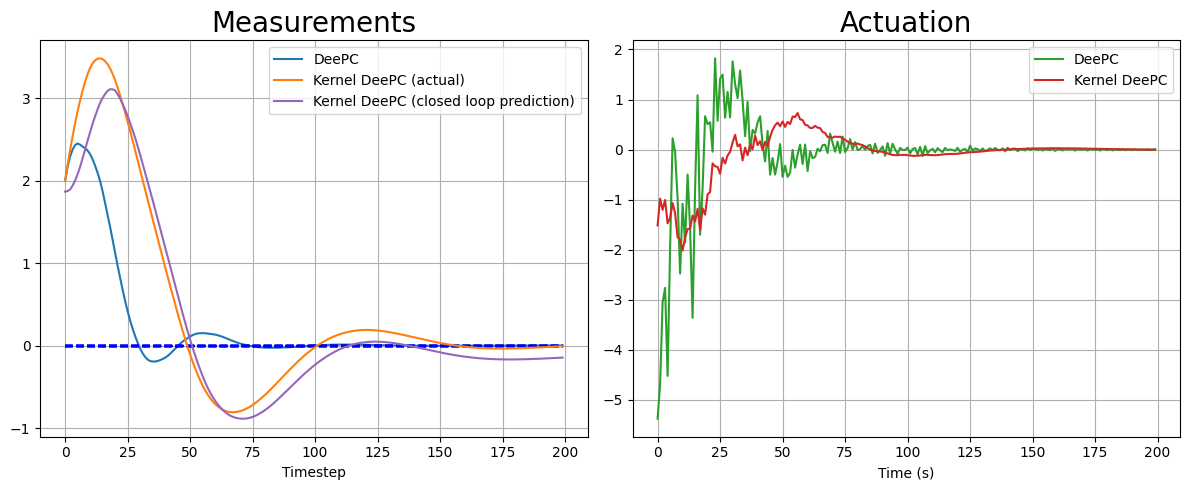

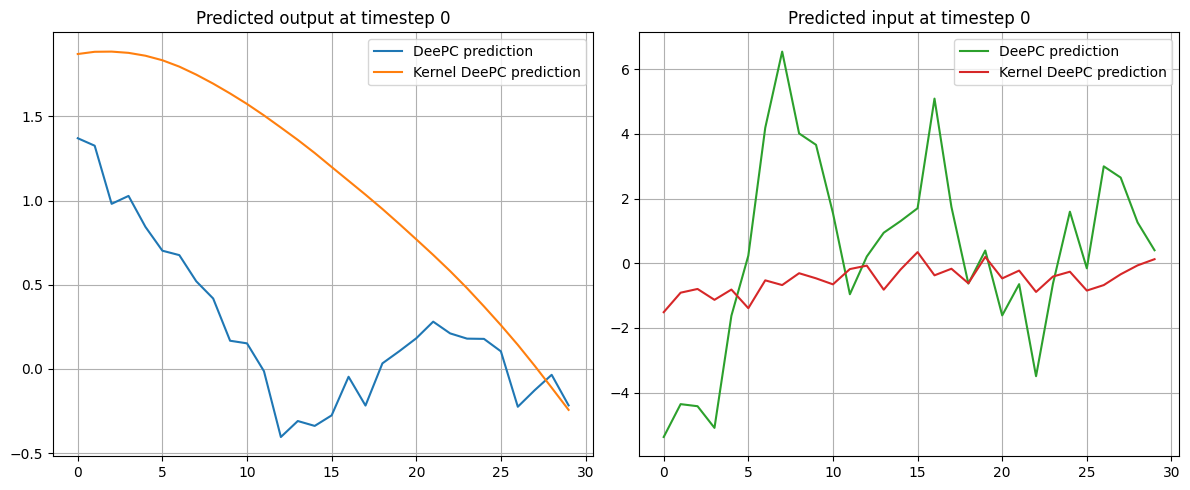

In [18]:
# Plot 1: Measurements and Actuations
plt.figure(figsize=(12,5))

# Measurements
plt.subplot(1,2,1)
plt.plot(range(0, T_sim), y_sim, label='DeePC', color='tab:blue')
plt.plot(range(0, T_sim), y_reference_sim, 'b--')
plt.plot(range(0, T_sim), y_sim_kernel, label='Kernel DeePC (actual)', color='tab:orange')
plt.plot(range(0, T_sim), y_sim_kernel_prediction, label='Kernel DeePC (closed loop prediction)', color='tab:purple')
plt.xlabel('Timestep')
plt.title("Measurements", fontdict={'fontsize':20})
plt.grid(True)
plt.legend()
plt.tight_layout()

# Actuations
plt.subplot(1,2,2)
plt.plot(range(0, T_sim), u_sim, label='DeePC', color='tab:green')
plt.plot(range(0, T_sim), u_sim_kernel, label='Kernel DeePC', color='tab:red')
plt.xlabel('Time (s)')
plt.title("Actuation", fontdict={'fontsize':20})
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# Predicted outputs and inputs (open loop)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(T_fut), y_fut_start, label='DeePC prediction', color='tab:blue')
plt.plot(range(T_fut), y_opt, label='Kernel DeePC prediction', color='tab:orange')
plt.title("Predicted output at timestep 0")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.subplot(1,2,2)
plt.plot(range(T_fut), u_fut_start, label='DeePC prediction', color='tab:green')
plt.plot(range(T_fut), u_opt, label='Kernel DeePC prediction', color='tab:red')
plt.title("Predicted input at timestep 0")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()
